In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Study population

In [2]:
# data_dir = '../datafiles/chexpert/'
# df_demo = pd.DataFrame(pd.read_excel(data_dir + 'CHEXPERT DEMO.xlsx', engine='openpyxl'))

# df_demo = df_demo.rename(columns={'PRIMARY_RACE': 'race'})
# df_demo = df_demo.rename(columns={'PATIENT': 'patient_id'})
# df_demo = df_demo.rename(columns={'GENDER': 'sex'})
# df_demo = df_demo.rename(columns={'AGE_AT_CXR': 'age'})
# df_demo = df_demo.rename(columns={'ETHNICITY': 'ethnicity'})
# df_demo = df_demo.drop(['sex', 'age'], axis=1)
# df_demo.head()

,patient_id,race,ethnicity
0,patient24428,White,Non-Hispanic/Non-Latino
1,patient48289,Other,Hispanic/Latino
2,patient33856,White,Non-Hispanic/Non-Latino
3,patient41673,Unknown,Unknown
4,patient48493,White,Non-Hispanic/Non-Latino


In [3]:
# df_data_split = pd.read_csv(data_dir + 'chexpert_split_2021_08_20.csv').set_index('index')

# df_img_data = pd.read_csv(data_dir + 'train.csv')

# df_img_data = pd.concat([df_img_data,df_data_split], axis=1)
# df_img_data = df_img_data[~df_img_data.split.isna()]

# split =  df_img_data.Path.str.split("/", expand = True)
# df_img_data["patient_id"] = split[2]
# df_img_data = df_img_data.rename(columns={'Age': 'age'})
# df_img_data = df_img_data.rename(columns={'Sex': 'sex'})
# df_img_data.head()

,Path,sex,age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,...,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,Unnamed: 0,split,patient_id
1,CheXpert-v1.0/train/patient00002/study2/view1_...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,...,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN,0.0,train,patient00002
2,CheXpert-v1.0/train/patient00002/study1/view1_...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,train,patient00002
4,CheXpert-v1.0/train/patient00003/study1/view1_...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,2.0,train,patient00003
5,CheXpert-v1.0/train/patient00004/study1/view1_...,Female,20,Frontal,PA,1.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,3.0,train,patient00004
7,CheXpert-v1.0/train/patient00005/study1/view1_...,Male,33,Frontal,PA,1.0,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,0.0,NaN,NaN,1.0,4.0,train,patient00005


In [4]:
# df_cxr = df_demo.merge(df_img_data, on="patient_id")
# df_cxr.head()

,patient_id,race,ethnicity,Path,sex,age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,...,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices,Unnamed: 0,split
0,patient24428,White,Non-Hispanic/Non-Latino,CheXpert-v1.0/train/patient24428/study22/view1...,Male,59,Frontal,AP,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,53688.0,train
1,patient24428,White,Non-Hispanic/Non-Latino,CheXpert-v1.0/train/patient24428/study39/view1...,Male,61,Frontal,PA,NaN,NaN,...,0.0,NaN,NaN,NaN,-1.0,NaN,NaN,NaN,53689.0,train
2,patient24428,White,Non-Hispanic/Non-Latino,CheXpert-v1.0/train/patient24428/study61/view1...,Male,61,Frontal,AP,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,53690.0,train
3,patient24428,White,Non-Hispanic/Non-Latino,CheXpert-v1.0/train/patient24428/study35/view1...,Male,60,Frontal,AP,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,53691.0,train
4,patient24428,White,Non-Hispanic/Non-Latino,CheXpert-v1.0/train/patient24428/study45/view1...,Male,61,Frontal,AP,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,53692.0,train


In [2]:
white = 'White'
asian = 'Asian'
black = 'Black'

root_dir = '/Users/calummaclellan/Documents/PhD/data/mimic-cxr/'
metadata_dir = root_dir + 'foundation-model-embeddings/'

df_cxr = pd.read_csv(metadata_dir + 'metadata_foundation_embeddings_numpy_raceLabels.csv')
display(df_cxr.shape)

df_cxr = df_cxr.rename(columns={'anchor_age': 'age'})
df_cxr = df_cxr.rename(columns={'gender': 'sex'})

(243324, 35)

In [10]:
# mask = (df_cxr.race.str.contains("Black", na=False))
# df_cxr.loc[mask, "race"] = black

# mask = (df_cxr.race.str.contains("White", na=False))
# df_cxr.loc[mask, "race"] = white

# mask = (df_cxr.race.str.contains("Asian", na=False))
# df_cxr.loc[mask, "race"] = asian

# df_cxr['race'].unique()

In [11]:
# df_cxr = df_cxr[df_cxr.race.isin([asian,black,white])]

In [12]:
# df_cxr = df_cxr[df_cxr.ethnicity.isin(["Non-Hispanic/Non-Latino","Not Hispanic"])]

In [13]:
# df_cxr = df_cxr[df_cxr["Frontal/Lateral"]=="Frontal"]

In [14]:
df_cxr.loc[df_cxr['race']=='WHITE', 'race'] = 'White'
df_cxr.loc[df_cxr['race']=='BLACK', 'race'] = 'Black'
df_cxr.loc[df_cxr['race']=='ASIAN', 'race'] = 'Asian'
df_cxr.loc[df_cxr['race']=='OTHER', 'race'] = 'Other'

display(df_cxr.head(10))

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,embeddings_file,subject_id,study_id,dicom_id,split,Atelectasis,Cardiomegaly,...,Columns,StudyDate,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,sex,age,race,embedding_array
0,0,0,0,files/p10/p10000032/s50414267/02aa804e-bde0afd...,10000032,50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,train,NaN,NaN,...,2544,21800506,213014.531,CHEST (PA AND LAT),postero-anterior,Erect,F,52.0,White,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.npy
1,1,1,1,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,10000032,53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,train,NaN,NaN,...,2544,21800626,165500.312,CHEST (PA AND LAT),postero-anterior,Erect,F,52.0,White,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.npy
2,2,2,2,files/p10/p10000032/s53911762/68b5c4b1-227d048...,10000032,53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,train,NaN,NaN,...,2539,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN,F,52.0,White,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.npy
3,3,3,3,files/p10/p10000032/s53911762/fffabebf-74fd3a1...,10000032,53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,train,NaN,NaN,...,2258,21800723,80556.875,CHEST (PORTABLE AP),antero-posterior,Erect,F,52.0,White,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.npy
4,4,4,4,files/p10/p10000032/s56699142/ea030e7a-2e3b134...,10000032,56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,train,NaN,NaN,...,2544,21800805,234424.765,CHEST (PORTABLE AP),antero-posterior,NaN,F,52.0,White,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.npy
5,5,5,5,files/p10/p10000764/s57375967/096052b7-d256dc4...,10000764,57375967,096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4,train,NaN,NaN,...,3056,21321015,84047.984,CHEST (PA AND LAT),antero-posterior,Erect,M,86.0,White,096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4.npy
6,6,6,6,files/p10/p10000898/s50771383/2a280266-c8bae12...,10000898,50771383,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,train,NaN,NaN,...,3056,21880312,125501.842,CHEST (PA AND LAT),postero-anterior,Erect,F,80.0,Other,2a280266-c8bae121-54d75383-cac046f4-ca37aa16.npy
7,7,7,7,files/p10/p10000898/s54205396/b75df1bd-0f22d63...,10000898,54205396,b75df1bd-0f22d631-52d73526-2ae7b85a-d843b39d,train,NaN,NaN,...,2544,21880113,140127.546,CHEST (PA AND LAT),postero-anterior,Erect,F,80.0,Other,b75df1bd-0f22d631-52d73526-2ae7b85a-d843b39d.npy
8,8,8,8,files/p10/p10000935/s50578979/d0b71acc-b5a6204...,10000935,50578979,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,train,NaN,NaN,...,2402,21871016,123945.421,CHEST (PORTABLE AP),antero-posterior,Erect,F,52.0,Black,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738.npy
9,9,9,9,files/p10/p10000935/s51178377/9b314ad7-fbcb042...,10000935,51178377,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,train,NaN,NaN,...,2544,21870823,191426.062,CHEST (PA AND LAT),antero-posterior,Erect,F,52.0,Black,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b.npy


In [15]:
df_cxr['race_label'] = df_cxr['race']

df_cxr.loc[df_cxr['race_label'] == white, 'race_label'] = 0
df_cxr.loc[df_cxr['race_label'] == asian, 'race_label'] = 1
df_cxr.loc[df_cxr['race_label'] == black, 'race_label'] = 2

In [18]:
df_cxr['sex_label'] = df_cxr['sex']

df_cxr.loc[df_cxr['sex_label'] == 'M', 'sex_label'] = 0
df_cxr.loc[df_cxr['sex_label'] == 'F', 'sex_label'] = 1

display(df_cxr.head(10))

,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,embeddings_file,subject_id,study_id,dicom_id,split,Atelectasis,Cardiomegaly,...,StudyTime,ProcedureCodeSequence_CodeMeaning,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,sex,age,race,embedding_array,race_label,sex_label
0,0,0,0,files/p10/p10000032/s50414267/02aa804e-bde0afd...,10000032,50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,train,NaN,NaN,...,213014.531,CHEST (PA AND LAT),postero-anterior,Erect,F,52.0,White,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.npy,0,1
1,1,1,1,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,10000032,53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,train,NaN,NaN,...,165500.312,CHEST (PA AND LAT),postero-anterior,Erect,F,52.0,White,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.npy,0,1
2,2,2,2,files/p10/p10000032/s53911762/68b5c4b1-227d048...,10000032,53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,train,NaN,NaN,...,80556.875,CHEST (PORTABLE AP),antero-posterior,NaN,F,52.0,White,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.npy,0,1
3,3,3,3,files/p10/p10000032/s53911762/fffabebf-74fd3a1...,10000032,53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,train,NaN,NaN,...,80556.875,CHEST (PORTABLE AP),antero-posterior,Erect,F,52.0,White,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.npy,0,1
4,4,4,4,files/p10/p10000032/s56699142/ea030e7a-2e3b134...,10000032,56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,train,NaN,NaN,...,234424.765,CHEST (PORTABLE AP),antero-posterior,NaN,F,52.0,White,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.npy,0,1
5,5,5,5,files/p10/p10000764/s57375967/096052b7-d256dc4...,10000764,57375967,096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4,train,NaN,NaN,...,84047.984,CHEST (PA AND LAT),antero-posterior,Erect,M,86.0,White,096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4.npy,0,0
6,6,6,6,files/p10/p10000898/s50771383/2a280266-c8bae12...,10000898,50771383,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,train,NaN,NaN,...,125501.842,CHEST (PA AND LAT),postero-anterior,Erect,F,80.0,Other,2a280266-c8bae121-54d75383-cac046f4-ca37aa16.npy,Other,1
7,7,7,7,files/p10/p10000898/s54205396/b75df1bd-0f22d63...,10000898,54205396,b75df1bd-0f22d631-52d73526-2ae7b85a-d843b39d,train,NaN,NaN,...,140127.546,CHEST (PA AND LAT),postero-anterior,Erect,F,80.0,Other,b75df1bd-0f22d631-52d73526-2ae7b85a-d843b39d.npy,Other,1
8,8,8,8,files/p10/p10000935/s50578979/d0b71acc-b5a6204...,10000935,50578979,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,train,NaN,NaN,...,123945.421,CHEST (PORTABLE AP),antero-posterior,Erect,F,52.0,Black,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738.npy,2,1
9,9,9,9,files/p10/p10000935/s51178377/9b314ad7-fbcb042...,10000935,51178377,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,train,NaN,NaN,...,191426.062,CHEST (PA AND LAT),antero-posterior,Erect,F,52.0,Black,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b.npy,2,1


In [19]:
labels = [
    'No Finding',
    'Enlarged Cardiomediastinum',
    'Cardiomegaly',
    'Lung Opacity',
    'Lung Lesion',
    'Edema',
    'Consolidation',
    'Pneumonia',
    'Atelectasis',
    'Pneumothorax',
    'Pleural Effusion',
    'Pleural Other',
    'Fracture',
    'Support Devices']

In [21]:
df_cxr['disease'] = df_cxr[labels[0]]
df_cxr.loc[df_cxr[labels[0]] == 1, 'disease'] = labels[0]
df_cxr.loc[df_cxr[labels[10]] == 1, 'disease'] = labels[10]
df_cxr.loc[df_cxr['disease'].isna(), 'disease'] = 'Other'

df_cxr['disease_label'] = df_cxr['disease']
df_cxr.loc[df_cxr['disease_label'] == labels[0], 'disease_label'] = 0
df_cxr.loc[df_cxr['disease_label'] == labels[10], 'disease_label'] = 1
df_cxr.loc[df_cxr['disease_label'] == 'Other', 'disease_label'] = 2

display(df_cxr.head(50))

/var/folders/rz/h7cm1h2j06vbbj_t9vl0ktk80000gn/T/ipykernel_26982/800230992.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No Finding' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cxr.loc[df_cxr[labels[0]] == 1, 'disease'] = labels[0]


,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,embeddings_file,subject_id,study_id,dicom_id,split,Atelectasis,Cardiomegaly,...,ViewCodeSequence_CodeMeaning,PatientOrientationCodeSequence_CodeMeaning,sex,age,race,embedding_array,race_label,sex_label,disease,disease_label
0,0,0,0,files/p10/p10000032/s50414267/02aa804e-bde0afd...,10000032,50414267,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014,train,NaN,NaN,...,postero-anterior,Erect,F,52.0,White,02aa804e-bde0afdd-112c0b34-7bc16630-4e384014.npy,0,1,No Finding,0
1,1,1,1,files/p10/p10000032/s53189527/2a2277a9-b0ded15...,10000032,53189527,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab,train,NaN,NaN,...,postero-anterior,Erect,F,52.0,White,2a2277a9-b0ded155-c0de8eb9-c124d10e-82c5caab.npy,0,1,No Finding,0
2,2,2,2,files/p10/p10000032/s53911762/68b5c4b1-227d048...,10000032,53911762,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714,train,NaN,NaN,...,antero-posterior,NaN,F,52.0,White,68b5c4b1-227d0485-9cc38c3f-7b84ab51-4b472714.npy,0,1,No Finding,0
3,3,3,3,files/p10/p10000032/s53911762/fffabebf-74fd3a1...,10000032,53911762,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818,train,NaN,NaN,...,antero-posterior,Erect,F,52.0,White,fffabebf-74fd3a1f-673b6b41-96ec0ac9-2ab69818.npy,0,1,No Finding,0
4,4,4,4,files/p10/p10000032/s56699142/ea030e7a-2e3b134...,10000032,56699142,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c,train,NaN,NaN,...,antero-posterior,NaN,F,52.0,White,ea030e7a-2e3b1346-bc518786-7a8fd698-f673b44c.npy,0,1,No Finding,0
5,5,5,5,files/p10/p10000764/s57375967/096052b7-d256dc4...,10000764,57375967,096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4,train,NaN,NaN,...,antero-posterior,Erect,M,86.0,White,096052b7-d256dc40-453a102b-fa7d01c6-1b22c6b4.npy,0,0,Other,2
6,6,6,6,files/p10/p10000898/s50771383/2a280266-c8bae12...,10000898,50771383,2a280266-c8bae121-54d75383-cac046f4-ca37aa16,train,NaN,NaN,...,postero-anterior,Erect,F,80.0,Other,2a280266-c8bae121-54d75383-cac046f4-ca37aa16.npy,Other,1,No Finding,0
7,7,7,7,files/p10/p10000898/s54205396/b75df1bd-0f22d63...,10000898,54205396,b75df1bd-0f22d631-52d73526-2ae7b85a-d843b39d,train,NaN,NaN,...,postero-anterior,Erect,F,80.0,Other,b75df1bd-0f22d631-52d73526-2ae7b85a-d843b39d.npy,Other,1,No Finding,0
8,8,8,8,files/p10/p10000935/s50578979/d0b71acc-b5a6204...,10000935,50578979,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738,train,NaN,NaN,...,antero-posterior,Erect,F,52.0,Black,d0b71acc-b5a62046-bbb5f6b8-7b173b85-65cdf738.npy,2,1,Pleural Effusion,1
9,9,9,9,files/p10/p10000935/s51178377/9b314ad7-fbcb042...,10000935,51178377,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b,train,NaN,NaN,...,antero-posterior,Erect,F,52.0,Black,9b314ad7-fbcb0422-6db62dfc-732858d0-a5527d8b.npy,2,1,Other,2


### Pre-processing of imaging dataset (this may take a few hours, needed only once)

In [ ]:
# point to the parent directory that contains the folder 'CheXpert-v1.0'
# img_data_dir = '<path_to_imaging_data>'

In [ ]:
# from skimage.io import imread
# from skimage.io import imsave
# from skimage.transform import resize

# df_cxr['path_preproc'] = df_cxr['Path']

# preproc_dir = 'preproc_224x224/'
# out_dir = img_data_dir

# if not os.path.exists(out_dir + preproc_dir):
#     os.makedirs(out_dir + preproc_dir)

# for idx, p in enumerate(tqdm(df_cxr['Path'])):

#     split =  p.split("/")
#     preproc_filename = split[2] + '_' + split[3] + '_' + split[4]
#     df_cxr.loc[idx, 'path_preproc'] = preproc_dir + preproc_filename
#     out_path = out_dir + preproc_dir + preproc_filename
    
#     if not os.path.exists(out_path):
#         image = imread(img_data_dir + p)
#         image = resize(image, output_shape=(224, 224), preserve_range=True)
#         imsave(out_path, image.astype(np.uint8))

### Save full sample

In [34]:
mask = (df_cxr.columns.str.contains("Unnamed", na=False))
print(mask)

# df = df_cxr.loc[df_cxr.columns == False]

df_cxr.to_csv(root_dir + 'MIMIC.sample.csv')

[ True  True  True False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False]


## Creating subsets

In [36]:
data_dir = root_dir
df_cxr = pd.read_csv(root_dir + 'MIMIC.sample.csv')

In [37]:
# df_train = df_cxr[df_cxr.split=="train"]
# df_val = df_cxr[df_cxr.split=="validate"]
# df_test = df_cxr[df_cxr.split=="test"]

#### Manually create subsets 
Splits provided in MIMIC-CXR dont give us enough testing data, but far more training data. Here I do it myself to give us around 140k testing.

In [39]:
seed = 42
num_train = 100000
num_val = 50000
num_test = int(len(df_cxr) - (num_train + num_val))

# training
df_train = df_cxr.sample(num_train, random_state=seed)

# validation: ensure no overlap with training
df_val = df_cxr.loc[~df_cxr['embedding_array'].isin(df_train['embedding_array'])]
df_val = df_val.sample(num_val, random_state=seed)
assert any(~df_train['embedding_array'].isin(df_val['embedding_array'])), 'Training/validation overlap.'

# testing: return embeddings not in either training or val
df_trainval_embeds = pd.concat([df_train, df_val], ignore_index=True)     
df_test = df_cxr.loc[~df_cxr['embedding_array'].isin(df_trainval_embeds['embedding_array'])]
assert (num_test == len(df_test)), 'Test set wrong size.'
  


In [40]:
df_train.to_csv(root_dir + 'MIMIC.sample.train.csv')
df_val.to_csv(root_dir + 'MIMIC.sample.val.csv')
df_test.to_csv(root_dir + 'MIMIC.sample.test.csv')

In [6]:
df_train = pd.read_csv(metadata_dir + 'MIMIC.sample.train.agebin.csv')
df_val = pd.read_csv(metadata_dir + 'MIMIC.sample.val.agebin.csv')
df_test = pd.read_csv(metadata_dir + 'MIMIC.sample.test.agebin.csv')


In [8]:
df_train['split'] = 'train'
df_val['split'] = 'validation'
df_test['split'] = 'test'
df = pd.concat([df_train, df_val, df_test], ignore_index=True)
df = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1', 'Unnamed: 0.2', 'Unnamed: 0.3', 'embeddings_file'])
df.to_csv(metadata_dir + 'MIMIC.sample.trainValTest.csv')

In [17]:
# df_train_white = df_train[df_train['race'] == white]
# df_val_white = df_val[df_val['race'] == white]
# df_train_white.to_csv(data_dir + 'MIMIC.sample.train.white.csv')
# df_val_white.to_csv(data_dir + 'MIMIC.sample.val.white.csv')

# df_cxr_white = df_cxr[df_cxr['race'] == white]
# df_cxr_asian = df_cxr[df_cxr['race'] == asian]
# df_cxr_black = df_cxr[df_cxr['race'] == black]

# df_test_white = df_test[df_test['race'] == white]
# df_test_asian = df_test[df_test['race'] == asian]
# df_test_black = df_test[df_test['race'] == black]

# df_train_asian = df_train[df_train['race'] == asian]
# df_train_black = df_train[df_train['race'] == black]

# df_val_asian = df_val[df_val['race'] == asian]
# df_val_black = df_val[df_val['race'] == black]

In [18]:
# df_train_male = df_train[df_train['sex'] == 'M']
# df_val_male = df_val[df_val['sex'] == 'M']
# df_train_male.to_csv(data_dir + 'MIMIC.sample.train.male.csv')
# df_val_male.to_csv(data_dir + 'MIMIC.sample.val.male.csv')

## Plots

In [42]:
df_cxr.loc[df_cxr['disease'] == 'Pleural Effusion', 'disease'] = 'Pleur. Eff.'
df_cxr.loc[df_cxr['disease'] == 'No Finding', 'disease'] = 'No Find.'

df_cxr.loc[df_cxr['sex'] == 'M', 'sex'] = 'Male'
df_cxr.loc[df_cxr['sex'] == 'F', 'sex'] = 'Female'


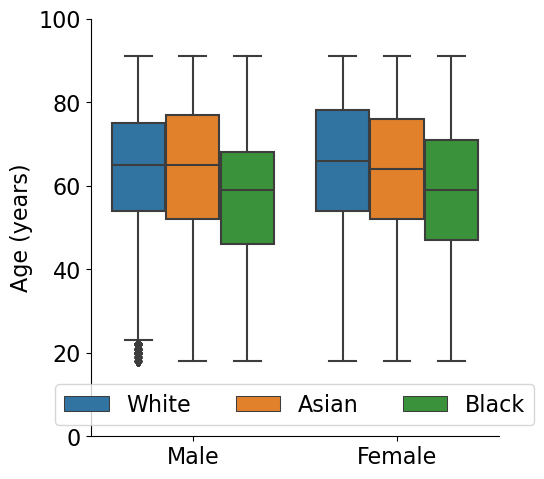

In [46]:
fontsize = 16
plt.rc('xtick', labelsize=fontsize) 
plt.rc('ytick', labelsize=fontsize)
fig = sns.catplot(x='sex', y='age', hue='race', order=['Male', 'Female'], hue_order=['White', 'Asian', 'Black'], kind="box", data=df_cxr)
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.legend(fontsize=fontsize, loc='lower center', ncol=3)
plt.show()
fig.savefig("MIMIC-CXR-age-sex-race.png", bbox_inches='tight', dpi=300)

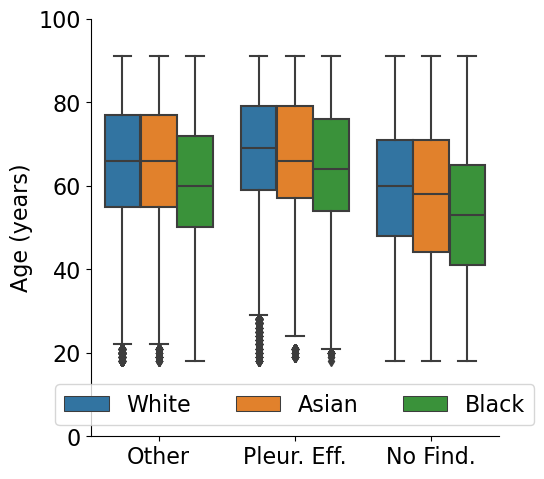

In [47]:
fig = sns.catplot(x='disease', y='age', hue='race', order=['Other', 'Pleur. Eff.', 'No Find.'], hue_order=['White', 'Asian', 'Black'], kind="box", data=df_cxr)
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.legend(fontsize=fontsize, loc='lower center', ncol=3)
plt.show()
fig.savefig("MIMIC-CXR-age-pathology-race.png", bbox_inches='tight', dpi=300)

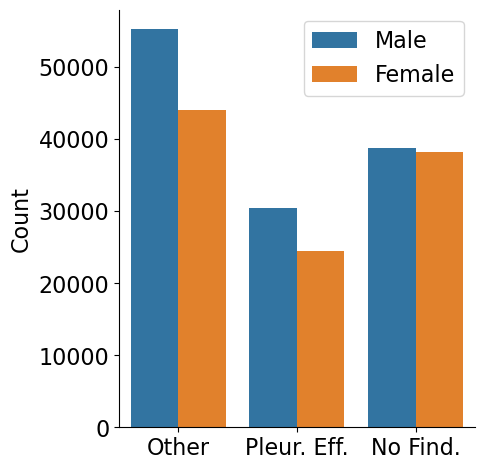

In [48]:
fig = sns.catplot(x='disease', hue='sex', order=['Other', 'Pleur. Eff.', 'No Find.'], hue_order=['Male', 'Female'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig('../notebooks/' + "MIMIC-CXR-sex-pathology.png", bbox_inches='tight', dpi=300)

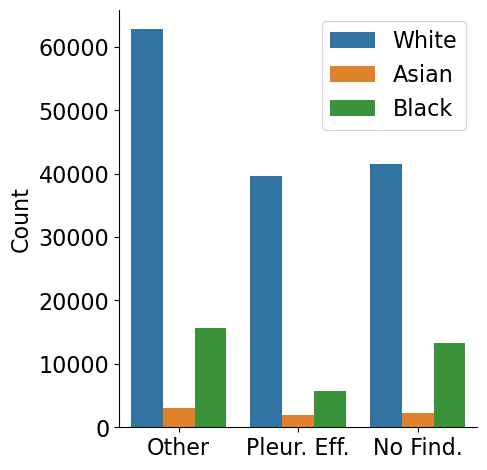

In [49]:
fig = sns.catplot(x='disease', hue='race', order=['Other', 'Pleur. Eff.', 'No Find.'], hue_order=['White', 'Asian', 'Black'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-race-pathology.png", bbox_inches='tight', dpi=300)

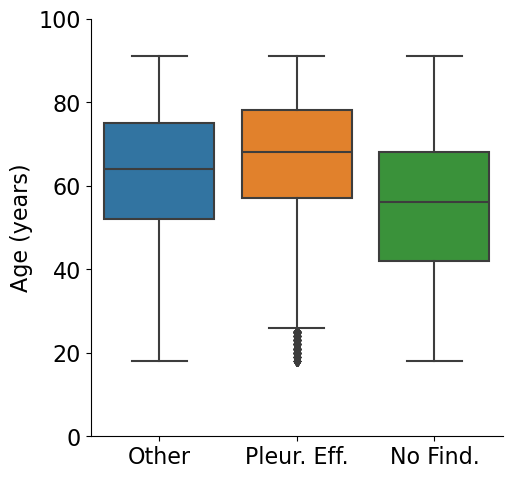

In [50]:
fig = sns.catplot(x='disease', y='age', order=['Other', 'Pleur. Eff.', 'No Find.'], kind="box", data=df_cxr)
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.show()
fig.savefig("MIMIC-CXR-age-pathology.png", bbox_inches='tight', dpi=300)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


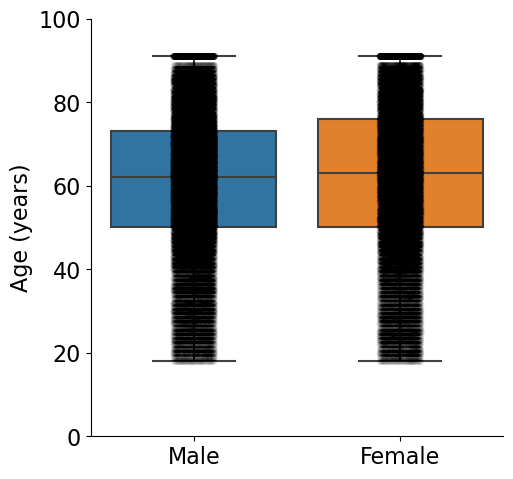

In [51]:
fig = sns.catplot(x='sex', y='age', order=['Male', 'Female'], kind="box", data=df_cxr)
sns.stripplot(x='sex', y='age', color='k', order=['Male', 'Female'], alpha=0.01, data=df_cxr, ax=fig.ax)
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.show()
fig.savefig("MIMIC-CXR-age-sex.png", bbox_inches='tight', dpi=300)

/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/envs/py-cxr/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


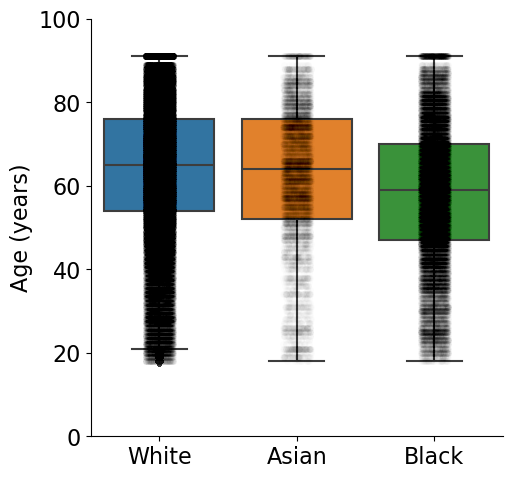

In [52]:
fig = sns.catplot(x='race', y='age', order=['White', 'Asian', 'Black'], kind="box", data=df_cxr)
sns.stripplot(x='race', y='age', color='k', order=['White', 'Asian', 'Black'], alpha=0.01, data=df_cxr, ax=fig.ax)
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Age (years)', fontsize=fontsize)
plt.ylim([0, 100])
plt.show()
fig.savefig("MIMIC-CXR-age-race.png", bbox_inches='tight', dpi=300)

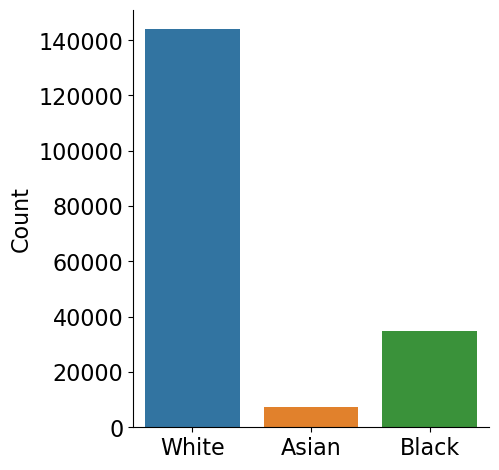

In [53]:
fig = sns.catplot(x='race', order=['White', 'Asian', 'Black'], data=df_cxr, kind='count')
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-race.png", bbox_inches='tight', dpi=300)

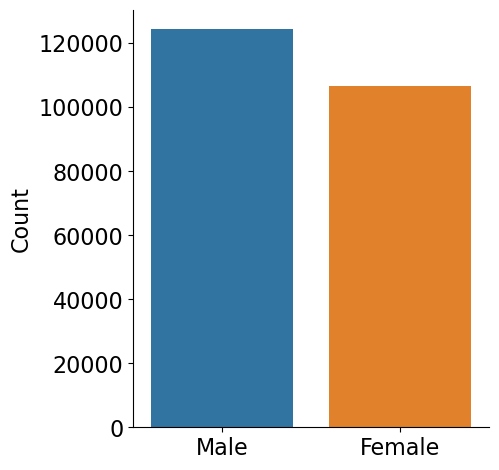

In [54]:
fig = sns.catplot(x='sex', order=['Male', 'Female'], data=df_cxr, kind='count')
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-sex.png", bbox_inches='tight', dpi=300)

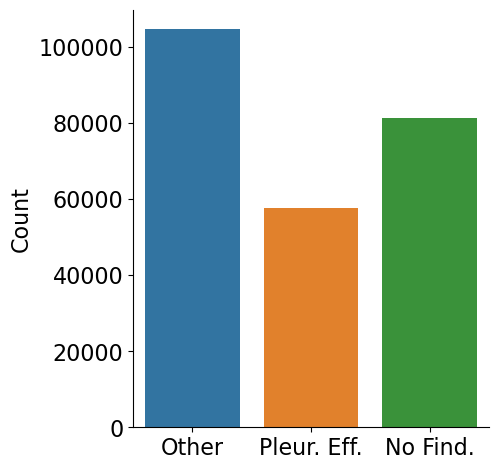

In [55]:
fig = sns.catplot(x='disease', order=['Other', 'Pleur. Eff.', 'No Find.'], data=df_cxr, kind='count')
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-pathology.png", bbox_inches='tight', dpi=300)

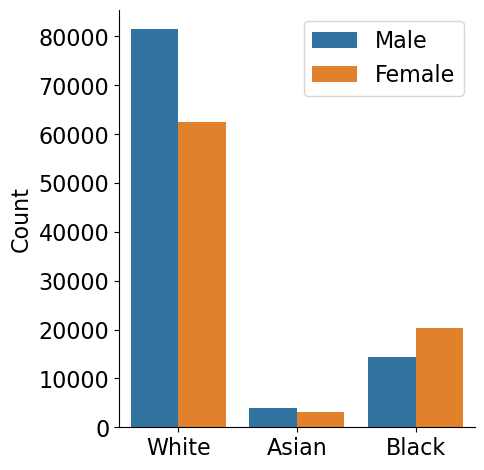

In [56]:
fig = sns.catplot(x='race', hue='sex', order=['White', 'Asian', 'Black'], hue_order=['Male', 'Female'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-sex-race.png", bbox_inches='tight', dpi=300)

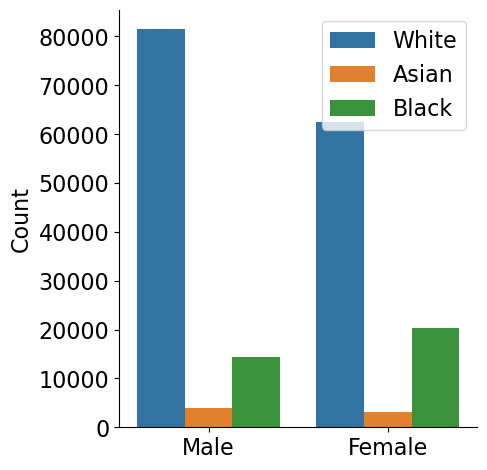

In [57]:
fig = sns.catplot(x='sex', hue='race', order=['Male', 'Female'], hue_order=['White', 'Asian', 'Black'], data=df_cxr, kind='count')
fig._legend.remove()
plt.xlabel('', fontsize=fontsize)
plt.ylabel('Count', fontsize=fontsize)
plt.legend(fontsize=fontsize)
plt.show()
fig.savefig("MIMIC-CXR-race-sex.png", bbox_inches='tight', dpi=300)